# Actividad en Clase: La ecuación de calor (FTCS)

Cristobal Medina Meza | A016413121

In [9]:
import numpy as np
from numpy.linalg import solve, norm
from numpy import pi,exp,sin,cos
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.animation as animation
import pandas as pd

### Solucion exacta

In [10]:
uexmp2 = np.loadtxt("data/uexmp2.csv", delimiter=",")
uexmp2 = uexmp2.T

### Parameter setup

In [16]:
xmin, xmax = 0, 1
N = 10
dx = (xmax-xmin)/N
x = np.linspace(xmin,xmax,N+1)

tmin, tmax = 0, 0.1
dt = 0.001
M = int((tmax-tmin)/dt)
t = np.linspace(tmin,tmax,M+1)

D = 1
s = D*dt/(dx*dx)

X,T = np.meshgrid(x,t)

In [17]:
(xmin,xmax),(tmin,tmax),N,M,D,dx,dt,s

((0, 1), (0, 0.1), 10, 100, 1, 0.1, 0.001, 0.09999999999999998)

### Initial condition

In [18]:
def f(x):
    return 1-4*(x-1/2)**2

### Initial graphs

In [19]:
tt = np.linspace(tmin,tmax,num=uexmp2.T.shape[0])
xx = np.linspace(xmin,xmax,num=uexmp2.T.shape[1])
XX,TT = np.meshgrid(xx,tt)

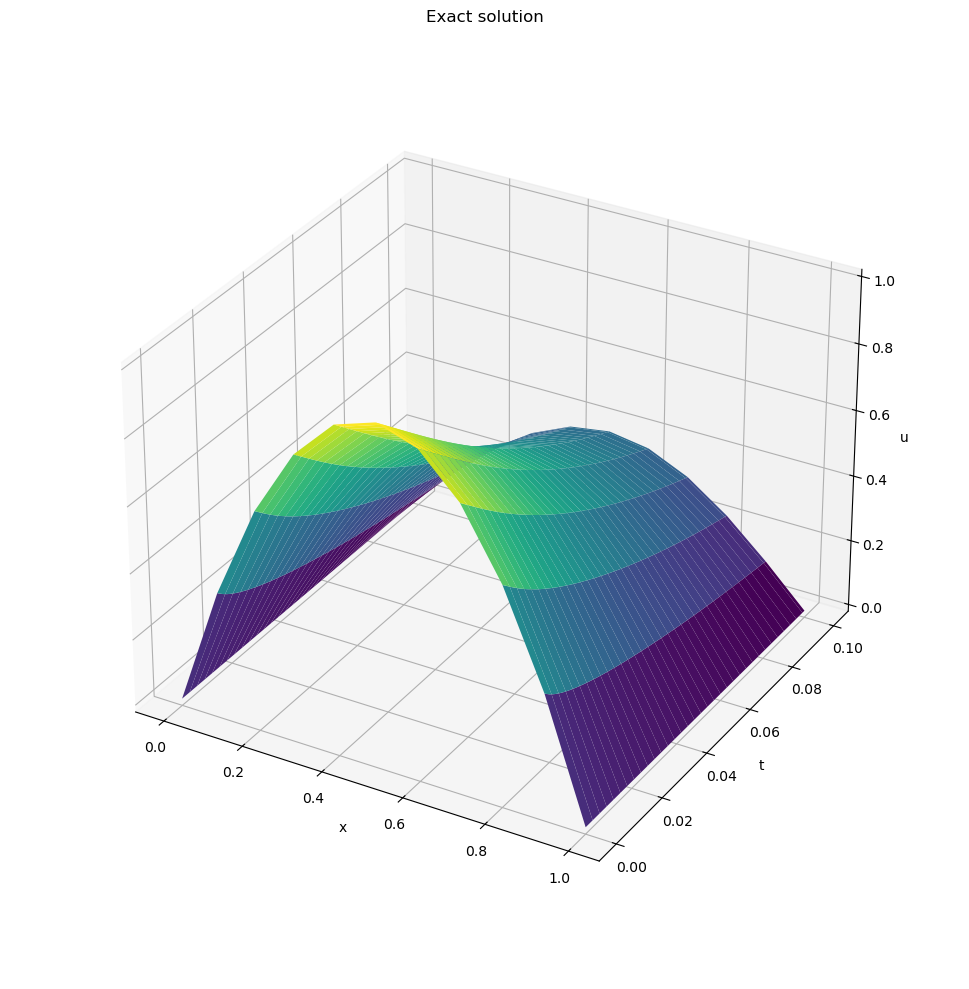

In [20]:
fig,ax = plt.subplots(subplot_kw={"projection": "3d"},figsize=(10,10), layout='tight')
ax.plot_surface(XX, TT, uexmp2.T,cmap=cm.viridis)
ax.set(title='Exact solution',xlabel='x',ylabel='t',zlabel='u')
ax.set_box_aspect(None, zoom=0.87)
plt.show()

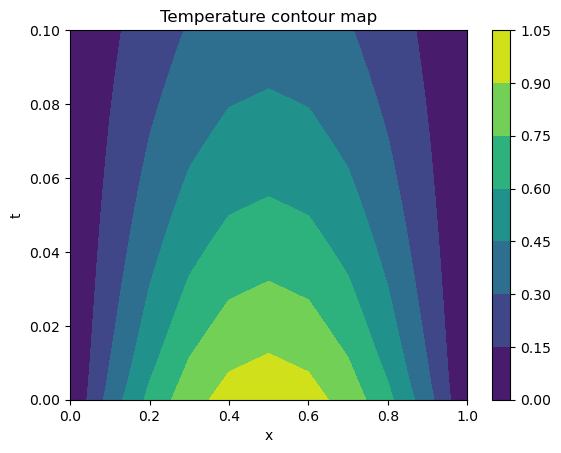

In [22]:
fig,ax = plt.subplots()
ct = ax.contourf(XX, TT, uexmp2.T);
fig.colorbar(ct)
ax.set(title='Temperature contour map',xlabel='x',ylabel='t')
plt.show()

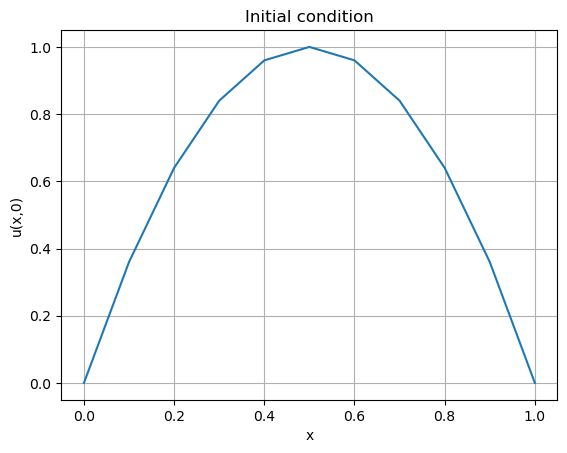

In [23]:
fig,ax = plt.subplots()
ax.plot(xx,f(xx));
ax.set(title="Initial condition",xlabel='x',ylabel='u(x,0)')
ax.grid()
plt.show()

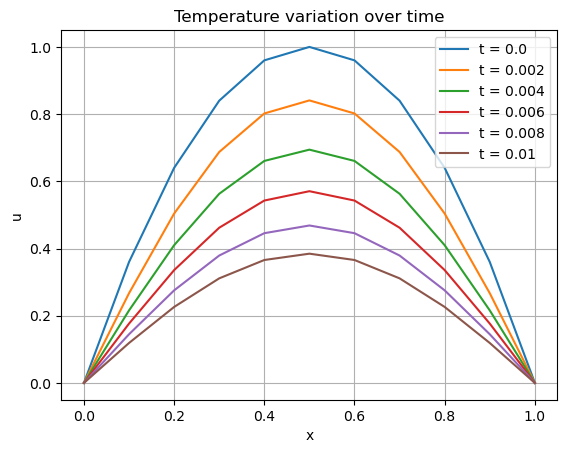

In [24]:
fig,ax = plt.subplots()
for k in range(0,6):
    ax.plot(xx,uexmp2[:,20*k],label=f't = {t[2*k]}')
ax.set(title='Temperature variation over time',xlabel='x',ylabel='u')
ax.grid()
ax.legend()
plt.show()

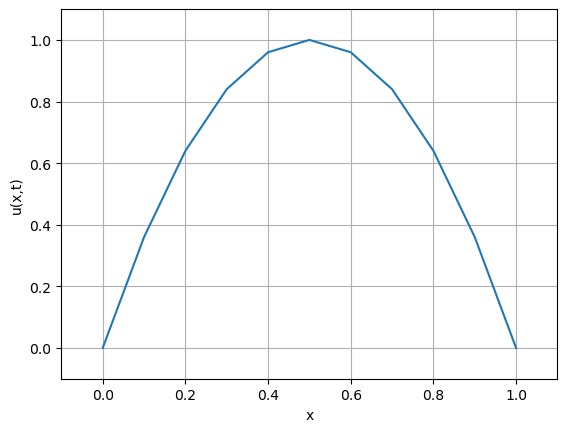

Animation saved successfully as heat_exmp_soln (mp4 and gif)


In [26]:
fig, ax = plt.subplots()
heat_exact, = ax.plot(xx,uexmp2[:,0]);

xlim = (-0.1, 1.1)
ylim = (-0.1, 1.1)
ax.set(xlabel='x',ylabel='u(x,t)',xlim=xlim,ylim=ylim)
ax.grid()

def animate(k):
    heat_exact.set_ydata(uexmp2[:,k])
    ax.set(title=f"Exact solution at t = {k*dt/10:.4f}")
    return heat_exact

ani = animation.FuncAnimation(fig, animate, frames=101)#, interval=500)

plt.show()

ani.save('heat_exmp_soln.mp4',fps=50)#, fps=30, extra_args=['-vcodec', 'libx264'])
ani.save('heat_exmp_soln.gif',fps=50)
print("Animation saved successfully as heat_exmp_soln (mp4 and gif)")

### Forward Euler

In [28]:
u = np.zeros((N+1,M+1))
u[:,0] = f(x)

for k in range(0,M):
    u[1:-1,k+1] = u[1:-1,k]+s*(u[2:,k]-2*u[1:-1,k]+u[:-2,k])

In [29]:
u_euler_fwd = u[:,:]

In [31]:
error1 = u_euler_fwd[:,:]-uexmp2[:,:]

In [32]:
print(f'Linf error = {norm(error1[:,M],ord=np.inf)}')

Linf error = 0.0012307270847578544


In [33]:
df_euler_fwd = pd.DataFrame(u_euler_fwd.T, columns = x, index = t)

In [34]:
df_euler_fwd

,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0
0.000,0.0,0.360000,0.640000,0.840000,0.960000,1.000000,0.960000,0.840000,0.640000,0.360000,0.0
0.001,0.0,0.352000,0.632000,0.832000,0.952000,0.992000,0.952000,0.832000,0.632000,0.352000,0.0
0.002,0.0,0.344800,0.624000,0.824000,0.944000,0.984000,0.944000,0.824000,0.624000,0.344800,0.0
0.003,0.0,0.338240,0.616080,0.816000,0.936000,0.976000,0.936000,0.816000,0.616080,0.338240,0.0
0.004,0.0,0.332200,0.608288,0.808008,0.928000,0.968000,0.928000,0.808008,0.608288,0.332200,0.0
...,...,...,...,...,...,...,...,...,...,...,...
0.096,0.0,0.124042,0.235936,0.324729,0.381732,0.401373,0.381732,0.324729,0.235936,0.124042,0.0
0.097,0.0,0.122827,0.233626,0.321550,0.377996,0.397445,0.377996,0.321550,0.233626,0.122827,0.0
0.098,0.0,0.121625,0.231339,0.318402,0.374296,0.393555,0.374296,0.318402,0.231339,0.121625,0.0
0.099,0.0,0.120433,0.229074,0.315285,0.370633,0.389703,0.370633,0.315285,0.229074,0.120433,0.0


In [35]:
df_euler_fwd_error = pd.DataFrame(error1.T, columns = x, index = t)

In [36]:
df_euler_fwd_error

,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0
0.000,0.0,-1.110223e-16,-1.110223e-16,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-5.551115e-17,0.0
0.001,0.0,-1.050252e-04,7.266325e-07,2.079197e-07,6.155533e-09,-4.000023e-12,6.155533e-09,2.079197e-07,7.266325e-07,-1.050252e-04,0.0
0.002,0.0,1.539708e-04,-6.004721e-06,-3.509049e-08,2.869178e-08,-3.876992e-09,2.869178e-08,-3.509049e-08,-6.004721e-06,1.539708e-04,0.0
0.003,0.0,3.541190e-04,2.983708e-05,1.399326e-09,1.496294e-08,7.989672e-10,1.496294e-08,1.399326e-09,2.983708e-05,3.541190e-04,0.0
0.004,0.0,4.776351e-04,9.814938e-05,4.710438e-06,9.114618e-09,1.787768e-09,9.114618e-09,4.710438e-06,9.814938e-05,4.776351e-04,0.0
...,...,...,...,...,...,...,...,...,...,...,...
0.096,0.0,3.780736e-04,7.196859e-04,9.924504e-04,1.169296e-03,1.230691e-03,1.169296e-03,9.924504e-04,7.196859e-04,3.780736e-04,0.0
0.097,0.0,3.783614e-04,7.200486e-04,9.926914e-04,1.169389e-03,1.230727e-03,1.169389e-03,9.926914e-04,7.200486e-04,3.783614e-04,0.0
0.098,0.0,3.786041e-04,7.203657e-04,9.928982e-04,1.169434e-03,1.230699e-03,1.169434e-03,9.928982e-04,7.203657e-04,3.786041e-04,0.0
0.099,0.0,3.788735e-04,7.207441e-04,9.931715e-04,1.169507e-03,1.230676e-03,1.169507e-03,9.931715e-04,7.207441e-04,3.788735e-04,0.0


#### Graphs

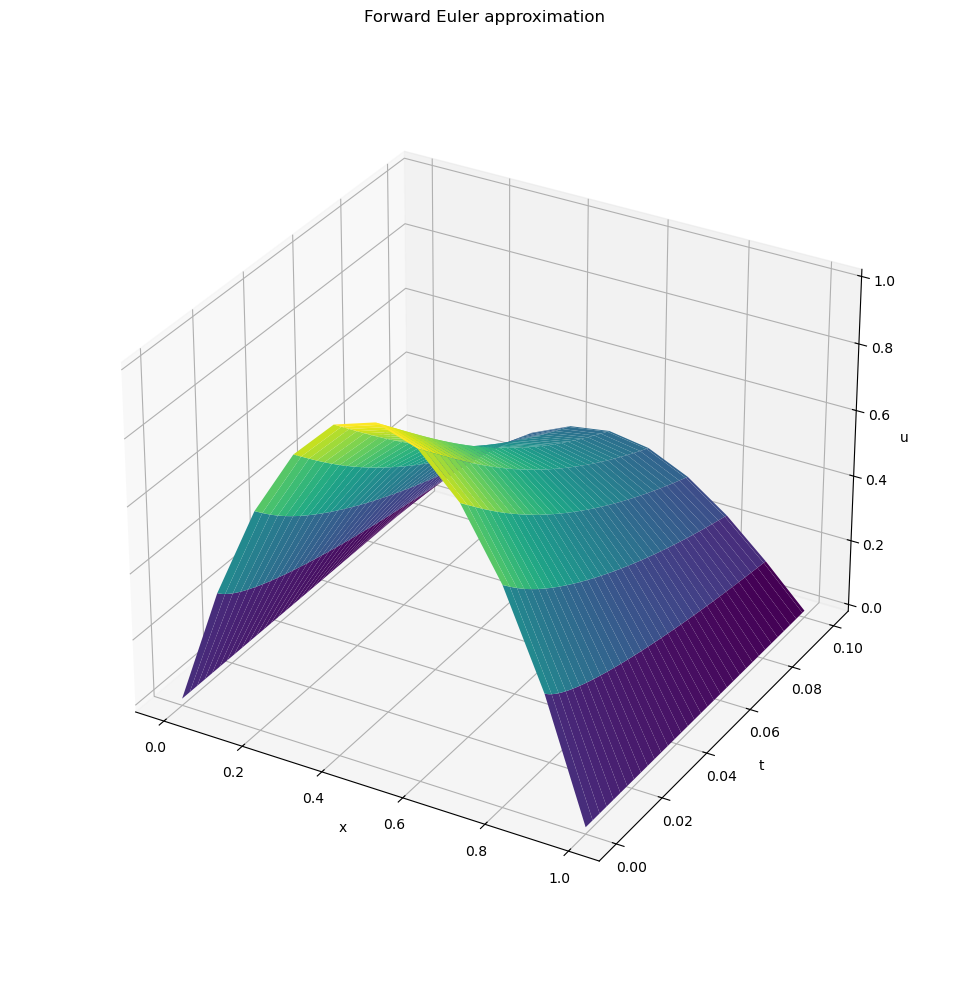

In [37]:
fig,ax = plt.subplots(subplot_kw={"projection": "3d"},figsize=(10,10), layout='tight')
ax.plot_surface(X, T, u_euler_fwd.T,cmap=cm.viridis)
ax.set(title='Forward Euler approximation',xlabel='x',ylabel='t',zlabel='u')
ax.set_box_aspect(None, zoom=0.87)
plt.show()

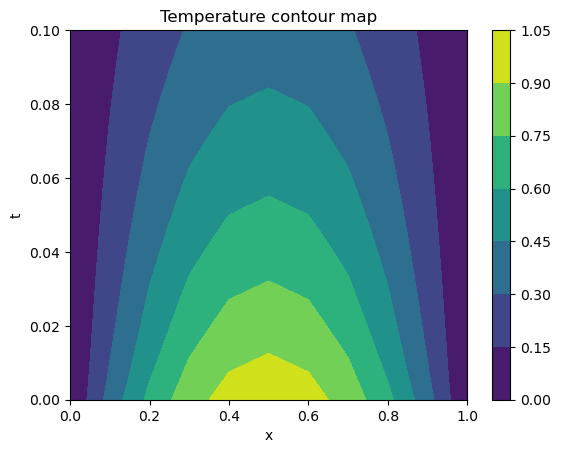

In [38]:
fig,ax = plt.subplots()
ct = ax.contourf(X, T, u_euler_fwd.T);
fig.colorbar(ct)
ax.set(title='Temperature contour map',xlabel='x',ylabel='t')
plt.show()

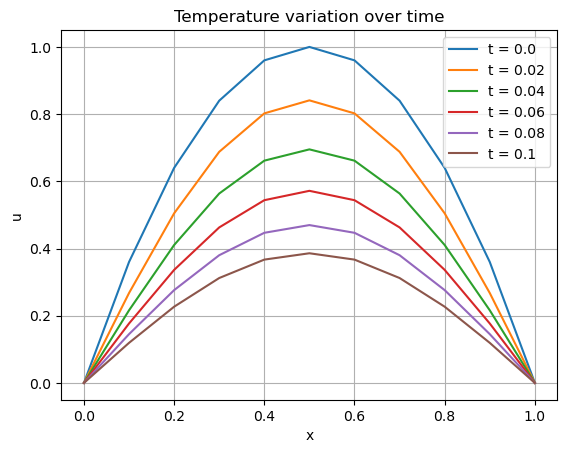

In [39]:
fig,ax = plt.subplots()
for k in range(0,M+1,M//5):
    ax.plot(x,u_euler_fwd[:,k],label=f't = {t[k]}')
ax.set(title='Temperature variation over time',xlabel='x',ylabel='u')
ax.grid()
ax.legend()
plt.show()

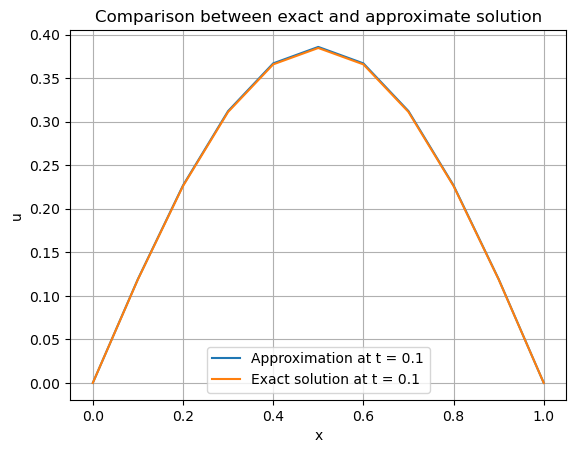

In [40]:
fig,ax = plt.subplots()
ax.plot(x,u_euler_fwd[:,M],label=f'Approximation at t = {t[M]}')
ax.plot(x,uexmp2[:,M],label=f'Exact solution at t = {tmax}')
ax.set(title='Comparison between exact and approximate solution',xlabel='x',ylabel='u')
ax.grid()
ax.legend()
plt.show()

In [41]:
error2 = u_euler_fwd[:,:]-uexmp2[:,:]

In [42]:
print(f'Linf error = {norm(error2[:,M],ord=np.inf)}')

Linf error = 0.0012307270847578544


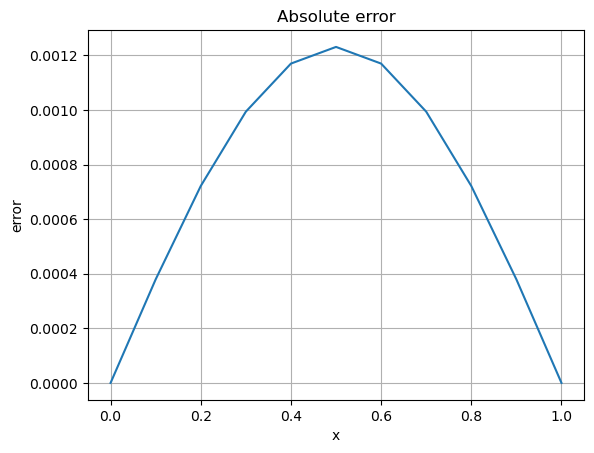

In [43]:
fig,ax = plt.subplots()
ax.plot(x,abs(error2[:,M]))
ax.set(title='Absolute error',xlabel='x',ylabel='error')
ax.grid()
plt.show()

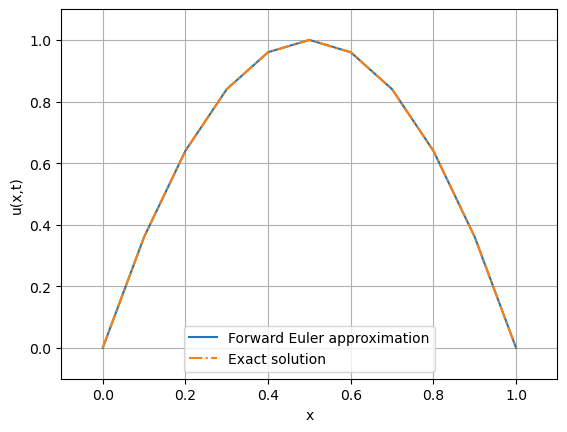

Animation saved successfully as heat_exmp2_fwd (mp4 and gif)


In [44]:
fig, ax = plt.subplots()

heat_approx, = ax.plot(x,u_euler_fwd[:,0],label='Forward Euler approximation');
heat_exact, = ax.plot(x,uexmp2[:,0],linestyle='-.',label='Exact solution');

ax.legend()
ax.set(xlabel='x',ylabel='u(x,t)',xlim=xlim,ylim=ylim)
ax.grid()

def animate(k):
    heat_approx.set_ydata(u_euler_fwd[:,k])
    heat_exact.set_ydata(uexmp2[:,k])
    ax.set(title=f"Exact solution vs Forward Euler approximation at t = {k*dt:.3f}")
    return heat_approx,heat_exact

ani = animation.FuncAnimation(fig, animate, frames=M+1)#, interval=500)

plt.show()

ani.save('heat_exmp2_fwd.mp4', fps=50)#, fps=30, extra_args=['-vcodec', 'libx264'])
ani.save('heat_exmp2_fwd.gif', fps=50)
print("Animation saved successfully as heat_exmp2_fwd (mp4 and gif)")

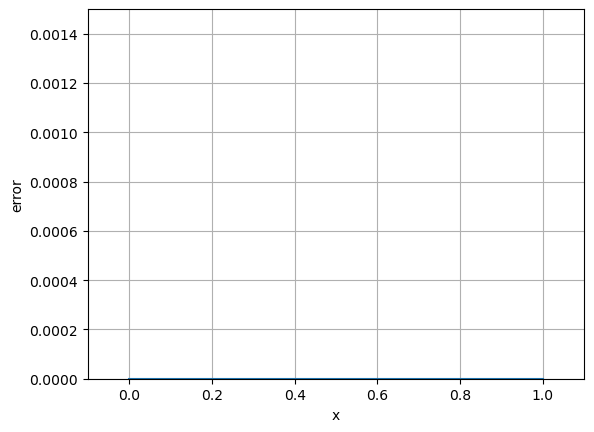

Animation saved successfully as heat_exmp2_fwd_error (mp4 and gif)


In [45]:
fig, ax = plt.subplots()

error, = ax.plot(x,abs(error2[:,0]));

#ax.legend()
ax.set(xlabel='x',ylabel='error',xlim=xlim,ylim=[0,1.5e-3])
ax.grid()

def animate(k):
    error.set_ydata(abs(error2[:,k]))
    ax.set(title=f"Error propagation. t = {k*dt:.3f}")
    return error

ani = animation.FuncAnimation(fig, animate, frames=M+1)#, interval=500)

plt.show()

ani.save('heat_exmp2_fwd_error.mp4', fps=50)#, fps=30, extra_args=['-vcodec', 'libx264'])
ani.save('heat_exmp2_fwd_error.gif', fps=50)
print("Animation saved successfully as heat_exmp2_fwd_error (mp4 and gif)")